expermiment 1: to analyze and compare the effect of stratified and non strafied train test splits on class distribution within training and testing test sets nad to evalute how stratification helps in preserving minority class representation for machine learning models

In [ ]:
import pandas as pd
df=pd.DataFrame({'feature': list(range(8))
,'target':['not fraud']*6+['fraud']*2})

In [ ]:
df

,feature,target
0,0,not fraud
1,1,not fraud
2,2,not fraud
3,3,not fraud
4,4,not fraud
5,5,not fraud
6,6,fraud
7,7,fraud


In [ ]:
x=df[['feature']]
y=df['target']

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test , y_train, y_test =train_test_split(x,y,test_size=0.5,random_state=0,
                                                   stratify=y)

In [ ]:
y_train

,target
1,not fraud
7,fraud
2,not fraud
4,not fraud


Experiment 2: to distinguish between encoding methods for categorical features and to apply approprite techniques- onehotencodeng for unordered (nominal) data and ordinalencodeing for ordered (ordinal) data

In [ ]:
import pandas as pd
X=pd.DataFrame({'Shape':['square','square', 'oval','circle'],
                 'Class':['third','first','second','third'],
                 'Size':['S','S','L','XL']})

In [ ]:
#"Shape" is unorderd , "Class" and "Size "are ordered
X

,Shape,Class,Size
0,square,third,S
1,square,first,S
2,oval,second,L
3,circle,third,XL


In [ ]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder

In [ ]:
#Left to right column order is alphabetical (circle,oval,square)
ohe=OneHotEncoder(sparse_output=False)
ohe.fit_transform (X[['Shape']])

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [ ]:
from collections import OrderedDict
#category ordering(within search feature) is defined by you
oe=OrdinalEncoder(categories=[['first','second','third'],
                              ['S','M','L','XL']])
oe.fit_transform(X[['Class','Size']])

array([[2., 0.],
       [0., 0.],
       [1., 2.],
       [2., 3.]])

Experiment 3: to apply diffrent preprocessing techniques to specific columns of a dataframes using the column transform and to analyze how onehotencoding , imputation and pass through transformations prepare heterogeneous data for machine learning models

In [ ]:
import pandas as pd
df=pd.read_csv('https://bit.ly/kaggletrain', nrows=6)

In [ ]:
cols=['Fare','Embarked','Sex','Age']
X=df[cols]

In [ ]:
X

,Fare,Embarked,Sex,Age
0,7.2500,S,male,22.0
1,71.2833,C,female,38.0
2,7.9250,S,female,26.0
3,53.1000,S,female,35.0
4,8.0500,S,male,35.0
5,8.4583,Q,male,NaN


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer

In [ ]:
ohe=OneHotEncoder()
imp=SimpleImputer()

In [ ]:
from math import remainder
ct=make_column_transformer(
    (ohe,['Embarked','Sex']),#apply one hot encoder to embarked and sex
    (imp,['Age']), #apply simpleimputer to age
    remainder='passthrough' # include reaminig columns (fare)in output
)

In [ ]:
#column order : embarked (3 columns ),sex(2 columns), age(1 column) , fare (1 column)
ct.fit_transform(X)

array([[ 0.    ,  0.    ,  1.    ,  0.    ,  1.    , 22.    ,  7.25  ],
       [ 1.    ,  0.    ,  0.    ,  1.    ,  0.    , 38.    , 71.2833],
       [ 0.    ,  0.    ,  1.    ,  1.    ,  0.    , 26.    ,  7.925 ],
       [ 0.    ,  0.    ,  1.    ,  1.    ,  0.    , 35.    , 53.1   ],
       [ 0.    ,  0.    ,  1.    ,  0.    ,  1.    , 35.    ,  8.05  ],
       [ 0.    ,  1.    ,  0.    ,  0.    ,  1.    , 31.2   ,  8.4583]])

expermnet : to train a decision tree classifier and ti visilize its structure using the function plot_tree and export_text, thereby interpreting how the models splits feature and makes classification decision

In [ ]:
import pandas as pd
df=pd.read_csv('https://bit.ly/kaggletrain')
df['Sex']=df["Sex"].map({'male':0 , 'feamle':1})

In [ ]:
feature=['Pclass', 'Fare', 'Sex']
X=df[feature]
y=df['Survived']

In [ ]:
classes=['Decreased','Survived']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=2, random_state=0)
dt.fit(X,y)

DecisionTreeClassifier(max_depth=2, random_state=0)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree , export_text

[Text(0.5, 0.8333333333333334, 'Pclass <= 2.5\ngini = 0.473\nsamples = 891\nvalue = [549, 342]\nclass = Decreased'),
 Text(0.25, 0.5, 'Fare <= 13.646\ngini = 0.493\nsamples = 400\nvalue = [177, 223]\nclass = Survived'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.435\nsamples = 94\nvalue = [64, 30]\nclass = Decreased'),
 Text(0.375, 0.16666666666666666, 'gini = 0.466\nsamples = 306\nvalue = [113, 193]\nclass = Survived'),
 Text(0.75, 0.5, 'Fare <= 10.825\ngini = 0.367\nsamples = 491\nvalue = [372, 119]\nclass = Decreased'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.325\nsamples = 328\nvalue = [261, 67]\nclass = Decreased'),
 Text(0.875, 0.16666666666666666, 'gini = 0.434\nsamples = 163\nvalue = [111.0, 52.0]\nclass = Decreased')]

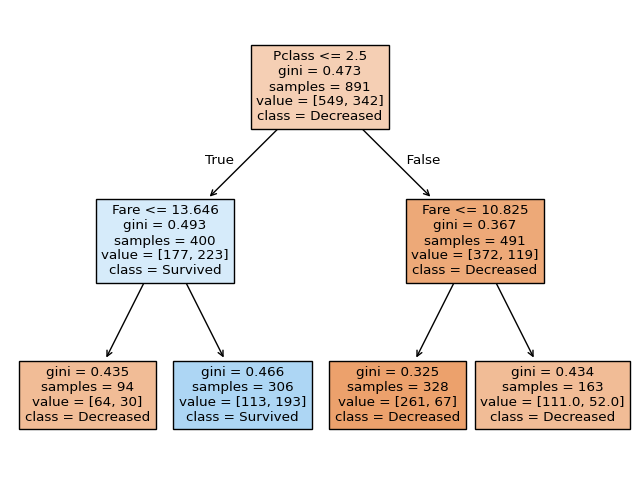

In [ ]:
plt.figure(figsize=(8,6))
plot_tree(dt,feature_names=feature, class_names=classes, filled=True)

Experinmnet : to apply different imputation strategies for handling mssing values in categorical feature and to analyze how each method effect the resulting data represntation

In [ ]:
import pandas as pd
import numpy as np
x= pd.DataFrame({'Shape':['square','square','oval','circle', np.nan]})

In [ ]:
x

,Shape
0,square
1,square
2,oval
3,circle
4,NaN


In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer=SimpleImputer(strategy='most_frequent')
imputer.fit_transform(x)

array([['square'],
       ['square'],
       ['oval'],
       ['circle'],
       ['square']], dtype=object)

In [ ]:
imputer =SimpleImputer(strategy='constant',fill_value='missing')
imputer.fit_transform(x)

array([['square'],
       ['square'],
       ['oval'],
       ['circle'],
       ['missing']], dtype=object)